In [1]:
import os
import sys
from typing import List, Sequence, Tuple, Optional

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.stats import f_oneway, kruskal, ttest_1samp, wilcoxon
import statsmodels.stats.multitest as smm

matplotlib.rcParams['font.size'] = 16.0

%matplotlib inline

sys.path.insert(0, '.')
from eykthyr.eykthyr import Eykthyr, load_anndata

os.makedirs('figure_panels', exist_ok=True)
sc.settings.figdir = 'figure_panels'

/work/magroup/skrieger/newconda/envs/eykthyr-new/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/work/magroup/skrieger/newconda/envs/eykthyr-new/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [2]:
def rank_and_plot_TFs(
    rdf,
    tf_groups,
    tf_group_labels=None,
    cols=None,
    ascendings=None,
    best_subset_idx=(0, 1, -2, -1),
    best_subset_labels=('Silhouette', 'iLISI', 'PCR', 'Overall'),
    figsize=(5,2),
    method_name='Eykthyr',
    num_tfs_total=None,
):
    if cols is None:
        cols = ['Silhouette batch', 'iLISI', 'KBET', 'Graph connectivity', 'PCR comparison', 'Batch correction']
    if ascendings is None:
        ascendings = [False, False, True, True, False, False]
    if tf_group_labels is None:
        tf_group_labels = [f'Group{i+1}' for i in range(len(tf_groups))]
    if num_tfs_total is None:
        num_tfs_total = rdf.shape[0]
    all_ranks = [[] for _ in tf_groups]

    for col, asc in zip(cols, ascendings):
        sorted_TFs = [attr.split('_')[2] for attr in rdf.sort_values(by=col, ascending=asc).index]
        group_ranks = []
        for tfs in tf_groups:
            ranks = [i for i, TF in enumerate(sorted_TFs) if TF in tfs]
            group_ranks.append(ranks)
        for i in range(len(all_ranks)):
            all_ranks[i].append(group_ranks[i])
        pvals = [ttest_1samp(r, len(rdf.index) / 2).pvalue for r in group_ranks]
        labels = [f'{lab}\n(p={p:.3f})' for lab, p in zip(tf_group_labels, pvals)]

    subset_ranks = [all_ranks[0][i] for i in best_subset_idx]
    norm_subset_ranks = [[r/num_tfs_total for r in p] for p in subset_ranks]
    return norm_subset_ranks

def rank_and_plot_TFs2(
    rdf: pd.DataFrame,
    tf_groups: List[List[str]],
    tf_group_labels: Optional[List[str]] = None,
    cols: Optional[List[str]] = None,
    ascendings: Optional[List[bool]] = None,
    best_subset_idx: Tuple[int, ...] = (0, 1, -2, -1),
    best_subset_labels: Tuple[str, ...] = ('Silhouette', 'iLISI', 'PCR', 'Overall'),
    figsize: Tuple[int, int] = (5, 2),
    method_name: str = 'Eykthyr',
    num_tfs_total: Optional[int] = None,
):
    if cols is None:
        cols = ['Silhouette batch', 'iLISI', 'KBET', 'Graph connectivity', 'PCR comparison', 'Batch correction']
    if ascendings is None:
        ascendings = [False, False, True, True, False, False]
    if tf_group_labels is None:
        tf_group_labels = [f'Group{i+1}' for i in range(len(tf_groups))]

    all_ranks: List[List[List[float]]] = [[] for _ in tf_groups]

    for col, asc in zip(cols, ascendings):
        sorted_attrs = rdf.sort_values(by=col, ascending=asc).index.tolist()
        sorted_TFs_raw = [a.split('_')[2] if len(a.split('_')) >= 3 else a for a in sorted_attrs]
        unique_sorted_TFs = list(dict.fromkeys(sorted_TFs_raw))
        n_present = len(unique_sorted_TFs)
        total_TFs = num_tfs_total if num_tfs_total is not None else n_present
        if total_TFs < n_present:
            total_TFs = n_present
        missing_rank_value = 0.5 * (n_present + total_TFs)
        rank_map = {tf: i for i, tf in enumerate(unique_sorted_TFs)}
        group_ranks: List[List[float]] = []
        for tfs in tf_groups:
            ranks = [float(rank_map[tf]) if tf in rank_map else float(missing_rank_value) for tf in tfs]
            group_ranks.append(ranks)
        for gi in range(len(all_ranks)):
            all_ranks[gi].append(group_ranks[gi])
        null_center = 0.5 * total_TFs
        pvals = [ttest_1samp(r, null_center).pvalue if len(r) > 0 else np.nan for r in group_ranks]
        labels = [f'{lab}\n(p={p:.3f})' if np.isfinite(p) else f'{lab}\n(p=NA)'
                  for lab, p in zip(tf_group_labels, pvals)]

    group_idx_for_summary = 0
    subset_ranks = [all_ranks[group_idx_for_summary][i] for i in best_subset_idx]
    norm_subset_ranks = [[r/num_tfs_total for r in p] for p in subset_ranks]
    global_total = num_tfs_total if num_tfs_total is not None else len(set([
        a.split('_')[2] if len(a.split('_')) >= 3 else a for a in rdf.index.tolist()]))
    return norm_subset_ranks

# Building normalized_ranks

In [3]:
normalized_ranks = {}

available_lit_TFs2 = ['Arx','Emx1','Emx2','Gli3','Lef1','Lhx2','Lmx1a','Nr2f1','Nr2f2','Otx1','Bhlhe22','Nr2e1','Pax6','Sp8']

leiden_labels = {
    '0': 'Midbrain 1',
    '1': 'Diencephalon',
    '2': 'Cartilage',
    '3': 'Midbrain 2',
    '4': 'Mesenchyme 1',
    '5': 'DPallm',
    '6': 'DPallv',
    '7': 'Subpallium',
    '8': 'Mesenchyme 2',
    '9': 'Muscle',
}

In [4]:
method_name = 'Eykthyr'
rdf = pd.read_csv('publication_figure_data/misar-seq/misar_pallium_metrics.csv')
rdf = rdf.set_index('Embedding')

cordf = pd.read_csv('publication_figure_data/misar-seq/co_misar_benchmarks.csv')
cordf = cordf.set_index('Embedding')
cordf = cordf.drop(index=['Metric Type'])

coTFs = [tf.split('_')[1] for tf in cordf.index]
sharedTFs = [tf for tf in rdf.index if tf.split('_')[2] in coTFs]
rdf = rdf.loc[sharedTFs]

ans = rank_and_plot_TFs(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    best_subset_labels=['Overall'],
    best_subset_idx=[-1],
    method_name=method_name,
    cols=['Batch correction'],
    num_tfs_total=622,
)
normalized_ranks[method_name] = ans[0]

In [5]:
method_name = 'Eykthyr (genes only)'
rdf = pd.read_csv('publication_figure_data/misar-seq/rdf_genes.csv')
rdf = rdf.set_index('Embedding')

ans = rank_and_plot_TFs(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    best_subset_labels=['Overall'],
    best_subset_idx=[-1],
    method_name=method_name,
    cols=['Batch correction'],
    num_tfs_total=622,
)
normalized_ranks[method_name] = ans[0]

In [6]:
method_name = 'Eykthyr (clusters only)'
rdf = pd.read_csv('publication_figure_data/misar-seq/rdf_cluster.csv')
rdf = rdf.set_index('Embedding')

ans = rank_and_plot_TFs(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    best_subset_labels=['Overall'],
    best_subset_idx=[-1],
    cols=['Batch correction'],
    num_tfs_total=622,
    method_name=method_name,
)
normalized_ranks[method_name] = ans[0]

In [7]:
method_name = 'Eykthyr (no ATAC)'
rdf = pd.read_csv('publication_figure_data/misar-seq/misar_pallium_metrics_noatac.csv')
rdf = rdf.set_index('Embedding')

ans = rank_and_plot_TFs(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    best_subset_labels=['Overall'],
    best_subset_idx=[-1],
    cols=['Batch correction'],
    num_tfs_total=622,
    method_name=method_name,
)
normalized_ranks[method_name] = ans[0]

In [10]:
eyk = load_anndata('publication_figure_data/misar-seq/eykthyrtest3.h5ad')
samples = ['E15_5-S2']
datasets = [eyk.perturbed_X[2]]
orig_datasets = [sc.read_h5ad(f'publication_figure_data/misar-seq/trained_K16_i200_differential_best_slices_simulation_{s}_X_norms.h5ad') for s in samples]
for d, o in zip(datasets, orig_datasets):
    d.obs['original_leiden'] = o.obs.loc[d.obs_names, 'original_leiden']
datasets[0].obs['labeled_leiden'] = [leiden_labels[c] for c in datasets[0].obs['original_leiden']]

TFs = eyk.TF[2]
for obsname in ['original_leiden', 'labeled_leiden']:
    TFs.obs[obsname] = datasets[0].obs.loc[TFs.obs_names, obsname]

groups = TFs.obs['labeled_leiden'].unique()
tf_names = TFs.var_names

f_stats = []
p_vals = []
for tf in tf_names:
    data_by_group = [TFs[:, tf].X[TFs.obs['labeled_leiden'] == g].toarray().ravel() for g in groups]
    f, p = f_oneway(*data_by_group)
    f_stats.append(f)
    p_vals.append(p)

df = pd.DataFrame({'TF': tf_names, 'F_stat': f_stats, 'p_val': p_vals})
df['-log10_p'] = -np.log10(df['p_val'] + 1e-300)
df = df.sort_values('F_stat', ascending=False).reset_index(drop=True)

cordf = pd.read_csv('publication_figure_data/misar-seq/co_misar_benchmarks.csv')
if 'Embedding' in cordf.columns:
    cordf = cordf.set_index('Embedding')
if 'Metric Type' in cordf.index:
    cordf = cordf.drop(index=['Metric Type'])
coTFs = {idx.split('_')[1] for idx in cordf.index}
shared_rows = [idx for idx in df['TF'] if idx in coTFs]
df.index = [f'Embedding_diff_{tf}' for tf in df['TF']]
s2 = [f'Embedding_diff_{tf}' for tf in shared_rows]
rdf = df.loc[s2]

method_name = 'F stat'
ans = rank_and_plot_TFs(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    cols=['F_stat'],
    ascendings=[False],
    best_subset_idx=[0],
    best_subset_labels=['F_stat'],
    figsize=(5, 2),
    num_tfs_total=622,
    method_name=method_name,
)
normalized_ranks[method_name] = ans[0]

/work/magroup/skrieger/newconda/envs/eykthyr-new/lib/python3.12/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/magroup/skrieger/newconda/envs/eykthyr-new/lib/python3.12/site-packages/popari/io.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  indices = merged_dataset.obs.groupby("batch").indices.values()


[2026/03/19 11:14:33]	 Reloading level 0


/work/magroup/skrieger/newconda/envs/eykthyr-new/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [11]:
h_stats = []
p_vals = []
for tf in tf_names:
    data_by_group = [TFs[:, tf].X[TFs.obs['labeled_leiden'] == g].toarray().ravel() for g in groups]
    h, p = kruskal(*data_by_group)
    h_stats.append(h)
    p_vals.append(p)

df = pd.DataFrame({'TF': tf_names, 'H_stat': h_stats, 'p_val': p_vals})
df['-log10_p'] = -np.log10(df['p_val'] + 1e-300)
df = df.sort_values('H_stat', ascending=False)

cordf = pd.read_csv('publication_figure_data/misar-seq/co_misar_benchmarks.csv')
if 'Embedding' in cordf.columns:
    cordf = cordf.set_index('Embedding')
if 'Metric Type' in cordf.index:
    cordf = cordf.drop(index=['Metric Type'])
coTFs = {idx.split('_')[1] for idx in cordf.index}
shared_rows = [idx for idx in df['TF'] if idx in coTFs]
df.index = [f'Embedding_diff_{tf}' for tf in df['TF']]
s2 = [f'Embedding_diff_{tf}' for tf in shared_rows]
rdf = df.loc[s2]

method_name = 'H stat'
ans = rank_and_plot_TFs(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    cols=['H_stat'],
    ascendings=[False],
    best_subset_idx=[0],
    best_subset_labels=['H_stat'],
    figsize=(5, 2),
    num_tfs_total=622,
    method_name=method_name,
)
normalized_ranks[method_name] = ans[0]

In [12]:
cluster_means = TFs.to_df().groupby(TFs.obs['labeled_leiden']).mean().T
cluster_means['mean_abs_dev'] = cluster_means.apply(lambda x: np.abs(x - x.mean()).mean(), axis=1)
df = cluster_means.sort_values('mean_abs_dev', ascending=False)
df['TF'] = df.index

cordf = pd.read_csv('publication_figure_data/misar-seq/co_misar_benchmarks.csv')
if 'Embedding' in cordf.columns:
    cordf = cordf.set_index('Embedding')
if 'Metric Type' in cordf.index:
    cordf = cordf.drop(index=['Metric Type'])
coTFs = {idx.split('_')[1] for idx in cordf.index}
shared_rows = [idx for idx in df['TF'] if idx in coTFs]
df.index = [f'Embedding_diff_{tf}' for tf in df['TF']]
s2 = [f'Embedding_diff_{tf}' for tf in shared_rows]
rdf = df.loc[s2]

method_name = 'Mean absolute deviation'
ans = rank_and_plot_TFs(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    cols=['mean_abs_dev'],
    ascendings=[False],
    best_subset_idx=[0],
    best_subset_labels=['mean_abs_dev'],
    figsize=(5, 2),
    num_tfs_total=622,
    method_name=method_name,
)
normalized_ranks[method_name] = ans[0]

In [13]:
method_name = 'SpaGRN'
rdf = pd.read_csv('publication_figure_data/misar-seq/rdf_spaGRN.csv')
rdf = rdf.set_index('Embedding')
rdf.index = [f'normalized_X_{k.split("_")[-1]}_dropout' for k in rdf.index]

ans = rank_and_plot_TFs2(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    method_name=method_name,
    best_subset_labels=['Overall'],
    best_subset_idx=[-1],
    cols=['Batch correction'],
    num_tfs_total=622,
)
normalized_ranks[method_name] = ans[0]

In [14]:
method_name = 'CellOracle'
rdf = pd.read_csv('publication_figure_data/misar-seq/co_misar_benchmarks.csv')
rdf = rdf.set_index('Embedding')
rdf = rdf.drop(index='Metric Type')
rdf.index = [f'normalized_X_{k.split("_")[1]}_dropout' for k in rdf.index]

ans = rank_and_plot_TFs(
    rdf,
    tf_groups=[available_lit_TFs2],
    tf_group_labels=['Set1'],
    best_subset_labels=['Overall'],
    best_subset_idx=[-1],
    cols=['Batch correction'],
    method_name=method_name,
)
normalized_ranks[method_name] = ans[0]

# Panel 2C

/tmp/ipykernel_467228/4130401654.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


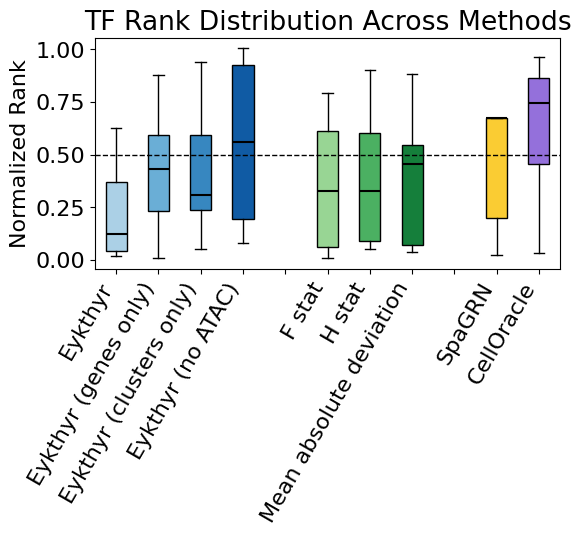

In [15]:
methods = list(normalized_ranks.keys())
values  = list(normalized_ranks.values())

# Grouping: first 4, next 3, last 2
groups = [values[:4], values[4:7], values[7:]]
labels = [methods[:4] + [''] + methods[4:7] + [''] + methods[7:]]  # blank labels for spacers

# Insert dummy NaN lists as separators
grouped_values = groups[0] + [np.nan] + groups[1] + [np.nan] + groups[2]

blues = sns.color_palette("Blues", 5)[1:]
greens = sns.color_palette("Greens", 4)[1:]
accents = [(0.98, 0.80, 0.20), (0.58, 0.44, 0.86)]
colors = blues + accents[:1] + greens[:3] + accents[:1] + accents

plt.figure(figsize=(6, 3))
bp = plt.boxplot(grouped_values, patch_artist=True)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_edgecolor("black")
    box.set_linewidth(1)

for med in bp['medians']:
    med.set_color("black")
    med.set_linewidth(1.5)

plt.ylabel("Normalized Rank")
plt.title("TF Rank Distribution Across Methods")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xticks(range(1, len(labels[0]) + 1), labels[0], rotation=60, ha='right')
plt.tight_layout()
plt.savefig('figure_panels/Panel_2C.svg', bbox_inches='tight')
plt.show()

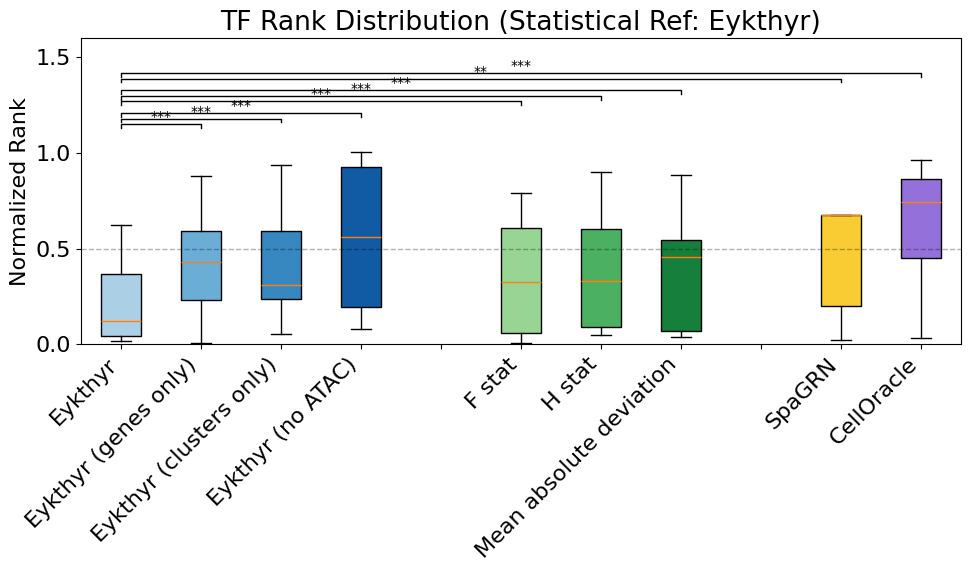

In [16]:
target_method = "Eykthyr"
methods = list(normalized_ranks.keys())
values = list(normalized_ranks.values())

# Grouping logic: 4, 3, 2
groups = [values[:4], values[4:7], values[7:]]
group_labels = [methods[:4], methods[4:7], methods[7:]]

grouped_values = groups[0] + [np.nan] + groups[1] + [np.nan] + groups[2]
labels = group_labels[0] + [""] + group_labels[1] + [""] + group_labels[2]

# Statistical calculations
comparison_pvals = []
comparison_indices = []
target_x = labels.index(target_method) + 1

for i, label in enumerate(labels):
    if label == "" or label == target_method:
        continue
    _, p = wilcoxon(normalized_ranks[target_method], normalized_ranks[label], alternative='less')
    comparison_pvals.append(p)
    comparison_indices.append(i + 1)

reject, pvals_corrected, _, _ = smm.multipletests(comparison_pvals, alpha=0.05, method='fdr_bh')

plt.figure(figsize=(10, 6))
bp = plt.boxplot(grouped_values, patch_artist=True)

blues = sns.color_palette("Blues", 5)[1:]
greens = sns.color_palette("Greens", 4)[1:]
accents = [(0.98, 0.80, 0.20), (0.58, 0.44, 0.86)]
colors = blues + [(1,1,1,0)] + greens + [(1,1,1,0)] + accents

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_edgecolor("black")
    box.set_linewidth(1)

# Significance brackets
for idx, p_corr, is_sig in zip(comparison_indices, pvals_corrected, reject):
    if not is_sig:
        continue
    if p_corr < 0.001: stars = "***"
    elif p_corr < 0.01: stars = "**"
    else: stars = "*"
    x1, x2 = target_x, idx
    y = 1.1 + (abs(x1 - x2) * 0.03)
    h = 0.02
    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c='black')
    plt.text((x1+x2)*.5, y+h, stars, ha='center', va='bottom', fontsize=10)

plt.ylabel("Normalized Rank")
plt.title(f"TF Rank Distribution (Statistical Ref: {target_method})")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.3)
plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right')
plt.ylim(0, 1.6)
plt.tight_layout()
plt.savefig('figure_panels/Panel_2C_with_Stats.svg', bbox_inches='tight')
plt.show()